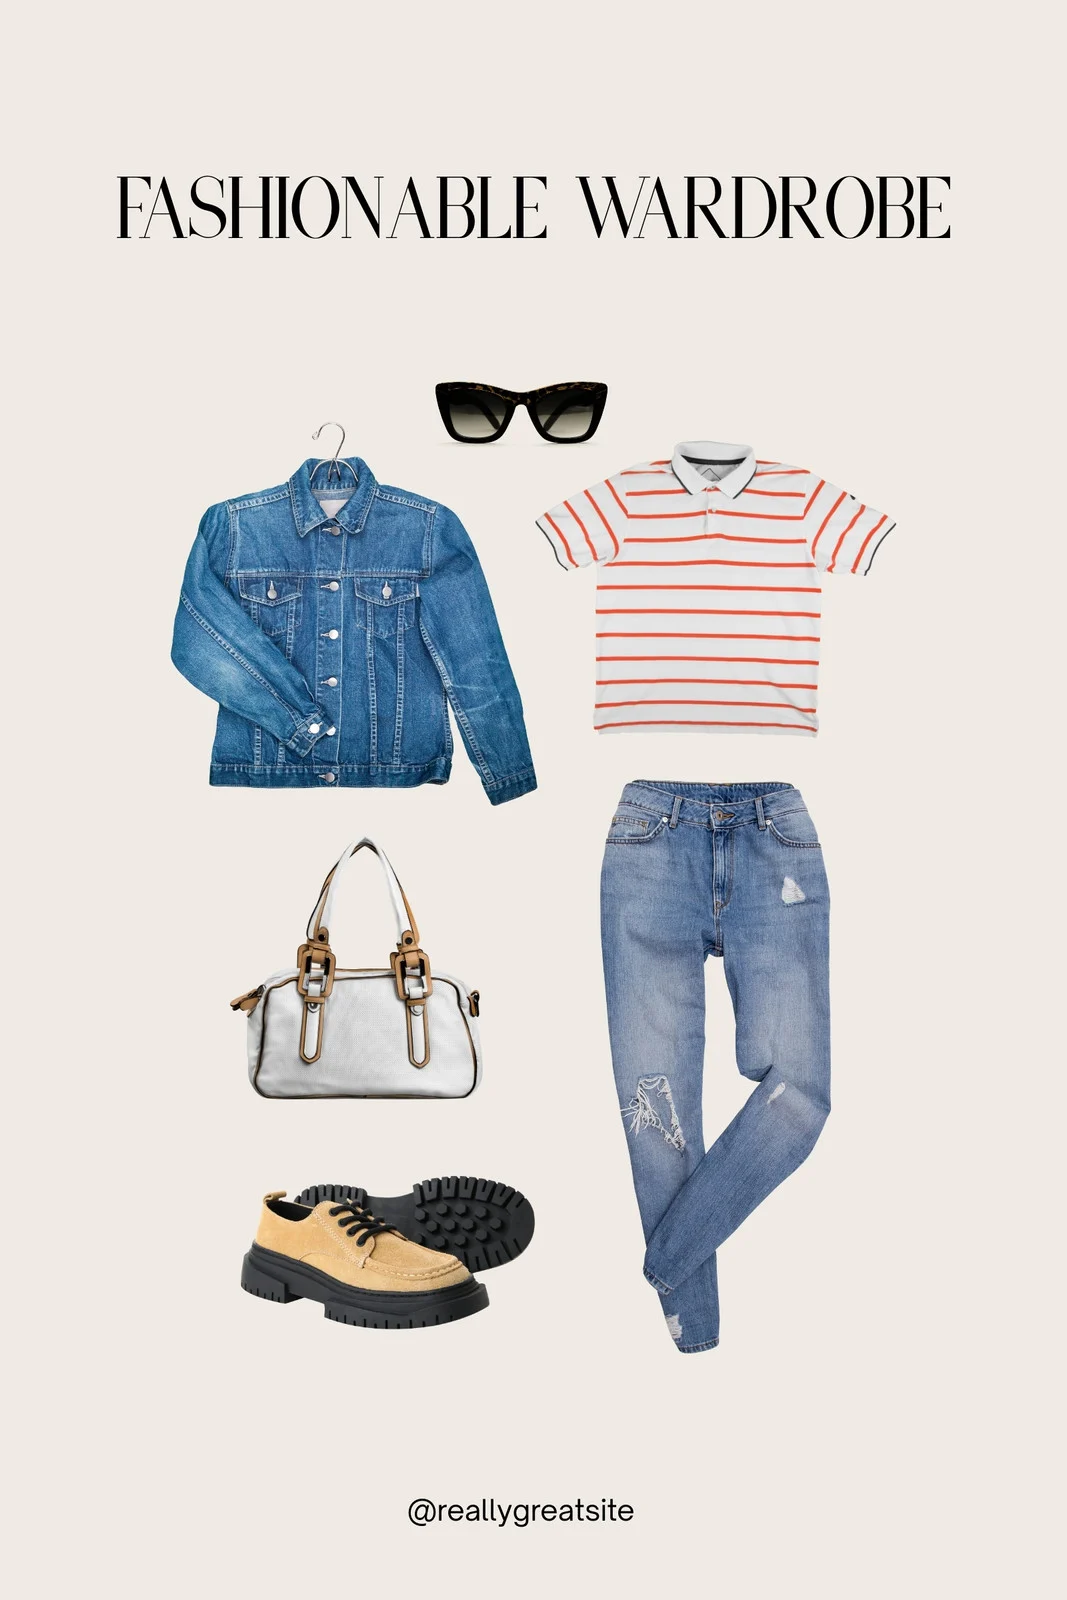

In [4]:
from pathlib import Path
from IPython.display import Image as DisplayImage, display
from PIL import Image as PILImage


canva_dir = Path('../datasets/original')
specs_dir = Path('../datasets/specs')

# Get all original Canva images (all formats)
canva_images = []
for ext in ['*.webp', '*.jpg', '*.jpeg', '*.png']:
    canva_images.extend(canva_dir.glob(ext))
canva_images = sorted(canva_images)

img_path = canva_images[0]
orig_w, orig_h = PILImage.open(img_path).size

# display at 1/4 the original width (keeps aspect ratio)
display(DisplayImage(filename=str(img_path), width=max(1, orig_w // 4)))


In [6]:
from transformers import AutoProcessor, AutoModelForVision2Seq

model_name = "Qwen/Qwen3-VL-2B-Thinking"

processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForVision2Seq.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

/Users/davidferris/Documents/envs/fonts-arm64/lib/python3.13/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


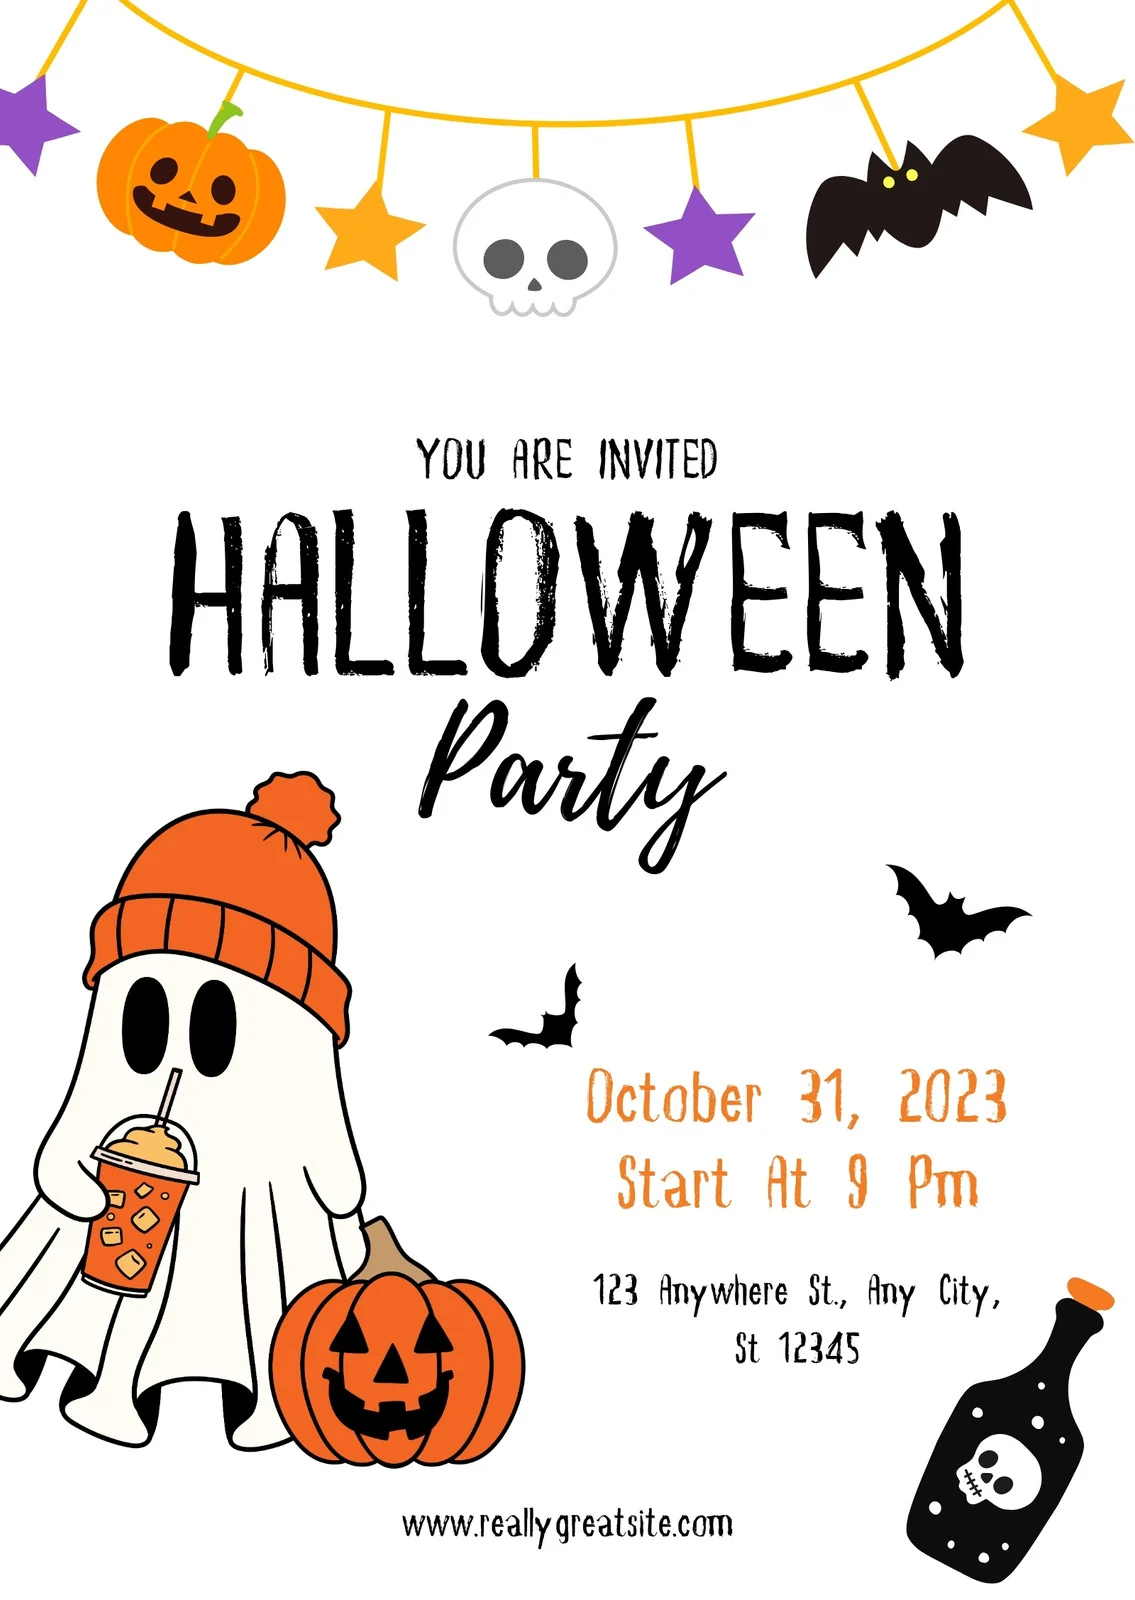

thinking content: Got it, let's tackle this. First, the image is a Halloween party invite. It has a spooky yet playful vibe with pumpkins, ghosts, bats, and festive colors. The text uses a mix of bold, hand-drawn fonts for "HALLOWEEN" and a script for "Party". The color palette is orange, black, white, with pops of purple and yellow.

So, font pairing: The main text has a bold, distressed sans-serif for "HALLOWEEN" (like a rugged, playful font) and a flowing script for "Party" (to add whimsy). Maybe pairing that with a clean sans-serif for body text to balance.

Color palette: The key colors are orange (pumpkins, drink), black (bones, bats), white (background), purple (stars), yellow (stars). So we need to match that. Maybe a warm orange and black with accents of purple and yellow for a Halloween theme.

Rationale: The design blends playful hand-drawn elements with bold typography, so the font pair should complement the energetic, festive mood. Colors should reflect Halloween’s iconic 

In [8]:
import random
from IPython.display import Image as DisplayImage, display
from PIL import Image as PILImage

# pick a random Canva image and show it at 1/4 size
rand_img = random.choice(canva_images)
pil_img = PILImage.open(rand_img).convert("RGB")
rw, rh = pil_img.size
display(DisplayImage(filename=str(rand_img), width=max(1, rw // 4)))

# build multimodal message with PIL image directly
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": pil_img},
            {"type": "text", "text": "Recommend a font pairing and color palette that match the style of this image. Provide a 1-sentence rationale and 3 concise bullet callouts."},
        ],
    }
]

# process inputs (apply_chat_template handles everything)
inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device)

# generate
outputs = model.generate(**inputs, max_new_tokens=8192)
output_ids = outputs[0][inputs["input_ids"].shape[-1]:].tolist()

# parse thinking content (151668 = </think>)
try:
    index = len(output_ids) - output_ids[::-1].index(151668)
except ValueError:
    index = 0

thinking_content = processor.decode(output_ids[:index], skip_special_tokens=True).strip("\n")
content = processor.decode(output_ids[index:], skip_special_tokens=True).strip("\n")

print("thinking content:", thinking_content)
print("content:", content)